In [16]:
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import accuracy_score


In [17]:
cols = ['name','landmass','zone','area','population','language','religion','bars','stripes','colours',
        'red','green','blue','gold','white','black','orange','mainhue','circles','crosses','saltires',
        'quarters','sunstars','crescent','triangle','icon','animate','text','topleft','botright']
df = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/flags/flag.data", names=cols)

In [18]:
var = ['red','green','blue','gold','white','black','orange','mainhue','bars','stripes',
       'circles','crosses','saltires','quarters','sunstars','triangle','animate']

# Europe + Oceania subset
df_36 = df[df["landmass"].isin([3,6])]
labels = (df_36["landmass"].isin([3,6]))*1
data = pd.get_dummies(df_36[var], drop_first=False)


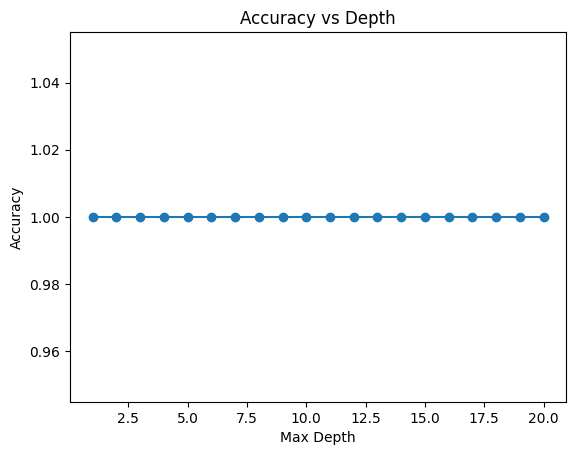

Best depth: 1 Accuracy: 1.0


In [19]:
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.3, random_state=42)

# Tune max_depth
depths = range(1, 21)
acc_depth = []
for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    acc_depth.append(accuracy_score(y_test, clf.predict(X_test)))

plt.plot(depths, acc_depth, marker='o')
plt.xlabel("Max Depth"); plt.ylabel("Accuracy"); plt.title("Accuracy vs Depth")
plt.show()

best_depth = depths[np.argmax(acc_depth)]
print("Best depth:", best_depth, "Accuracy:", np.max(acc_depth))

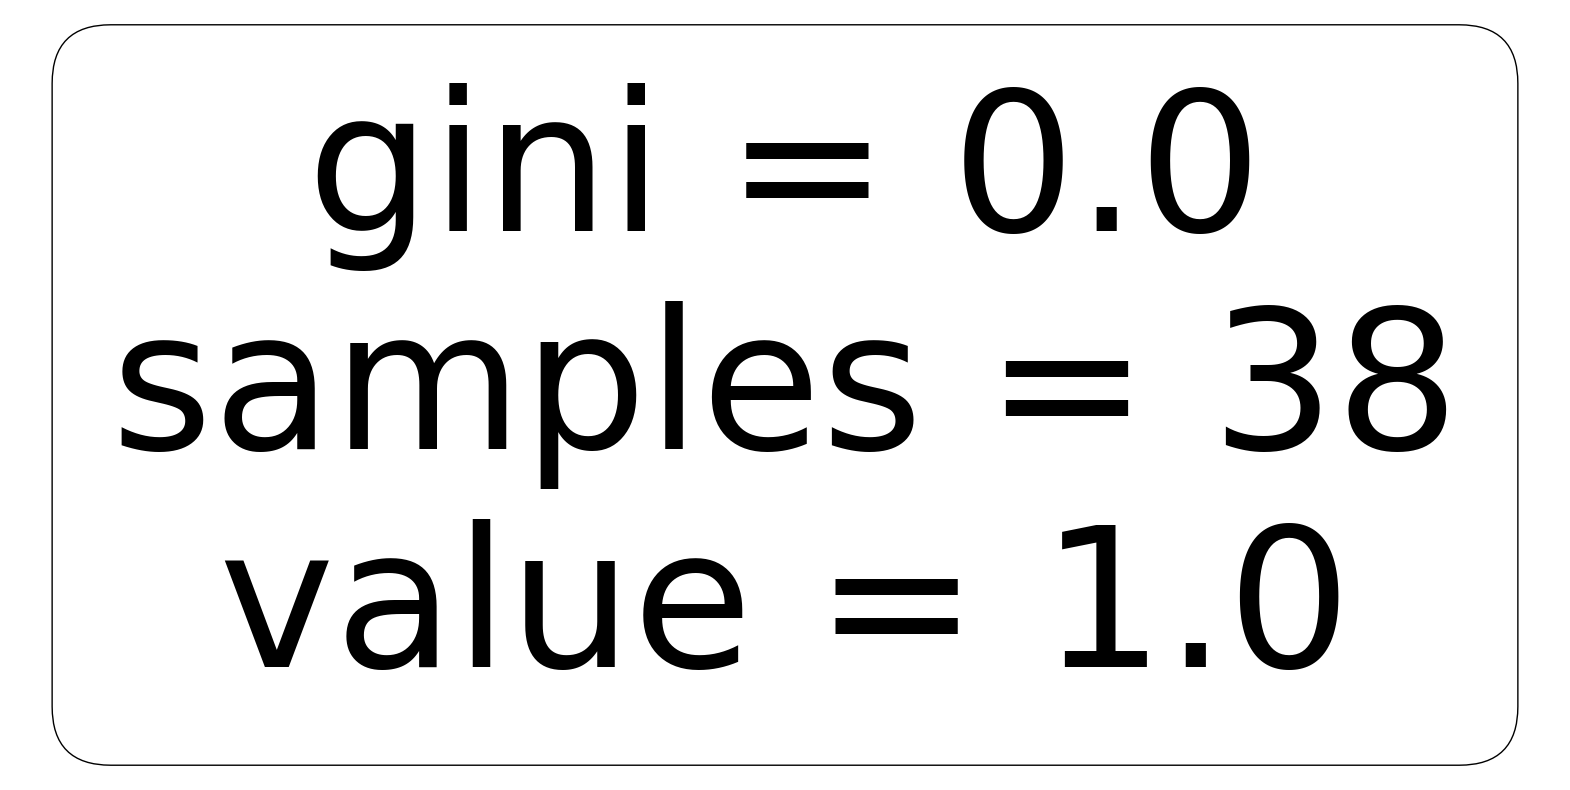

In [20]:
# Plot tree with best depth
clf = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
clf.fit(X_train, y_train)
plt.figure(figsize=(20,10))
plot_tree(clf, feature_names=data.columns, class_names=["Europe","Oceania"], filled=True, rounded=True)
plt.show()

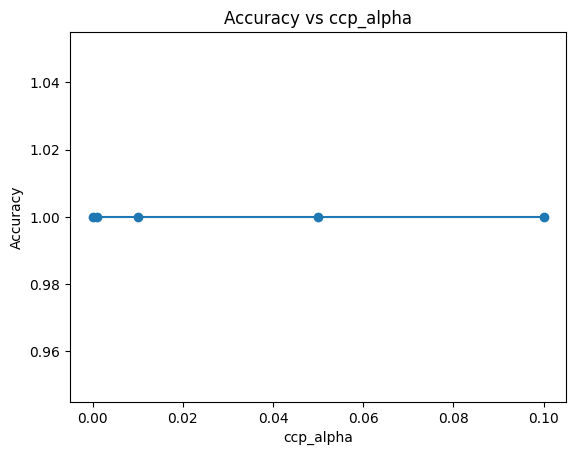

Best ccp_alpha: 0.0 Accuracy: 1.0


In [21]:
# Tune ccp_alpha
ccp = [0.0, 0.001, 0.01, 0.05, 0.1]
acc_pruned = []
for alpha in ccp:
    clf = DecisionTreeClassifier(max_depth=best_depth, ccp_alpha=alpha, random_state=42)
    clf.fit(X_train, y_train)
    acc_pruned.append(accuracy_score(y_test, clf.predict(X_test)))

plt.plot(ccp, acc_pruned, marker='o')
plt.xlabel("ccp_alpha"); plt.ylabel("Accuracy"); plt.title("Accuracy vs ccp_alpha")
plt.show()

best_alpha = ccp[np.argmax(acc_pruned)]
print("Best ccp_alpha:", best_alpha, "Accuracy:", np.max(acc_pruned))

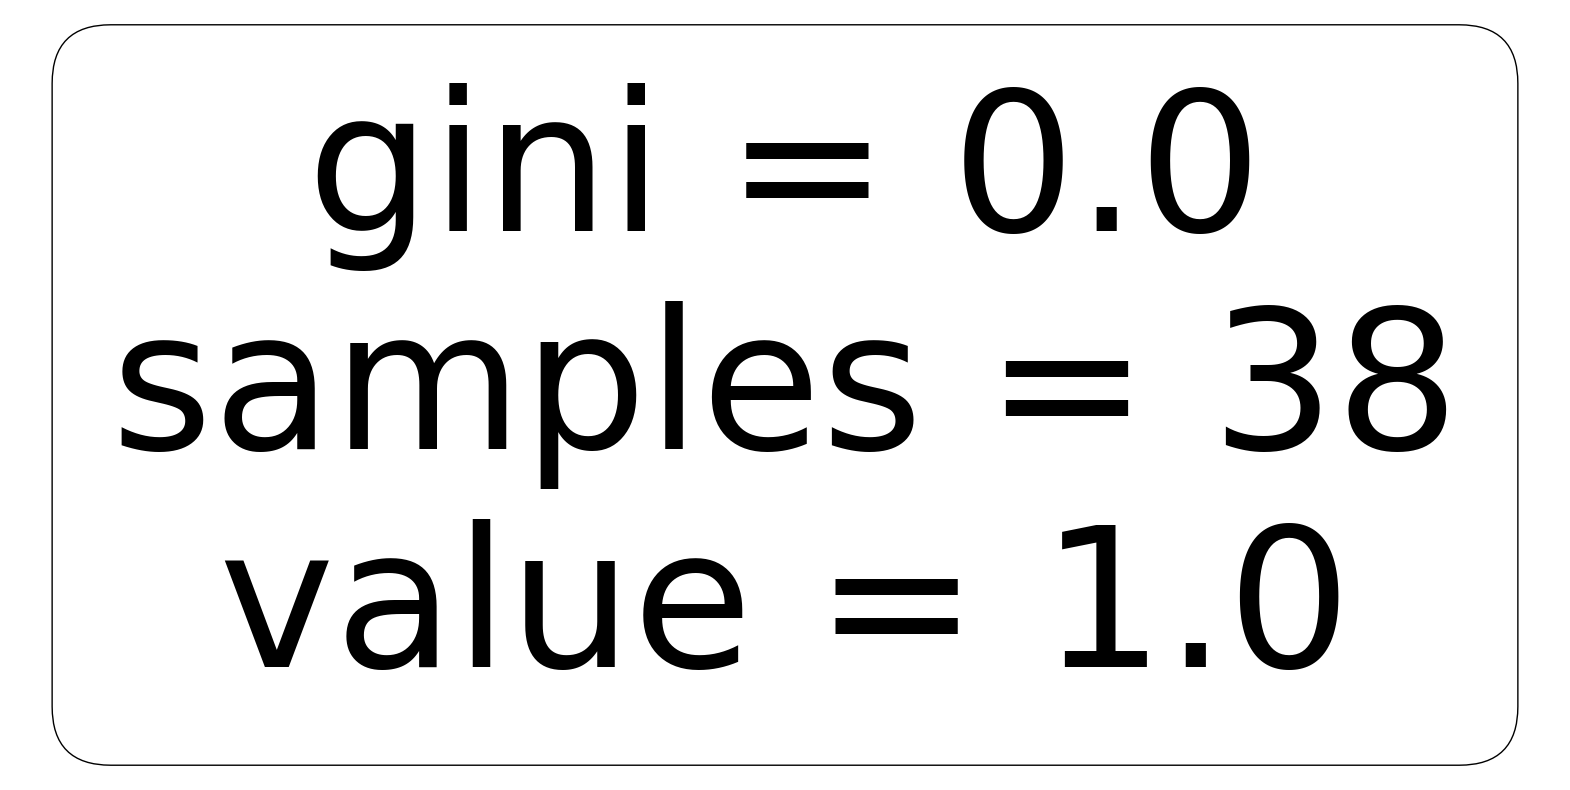

In [ ]:
# Final tree with best depth + alpha
clf = DecisionTreeClassifier(max_depth=best_depth, ccp_alpha=best_alpha, random_state=42)
clf.fit(X_train, y_train)
plt.figure(figsize=(20,10))
tree.plot_tree(clf, 
          feature_names=data.columns,   
          class_names=["Europe","Oceania"],
          filled=True, 
          rounded=True)
plt.show()